# Lensing bands and emission times in Jipole

Purely geometric: no GRMHD dump is read. The `Analytic` model is used only to provide the native
coordinates (MKS with `hslope = 1`) and the units; its emissivity is never evaluated.

* A pixel belongs to band $n$ when its ray crosses the midplane at least $n+1$ times
  (`midplane_crossings` returned by `get_pixel`).
* The time of band $n$ is Jipole's `X[1]` at the $(n+1)$-th crossing counted from the camera,
  without any rescaling (the camera sits at `X[1] = 0`, so times are negative).
* The number of bands is read from the data, not assumed.

In [1]:
using Jipole, StaticArrays, Statistics, Printf, ProgressMeter, CairoMakie

# Same black hole and camera as SlowLightGRMHD.ipynb
const spin     = 0.9375
const MBH      = 6.2e9
const SourceD  = 16.9e6 * Jipole.Constants.PC
const ro       = 1000.0          # camera distance (M)
const th       = 140.0 #163.0           # camera colatitude (deg)
const phi      = 0.0
const FOV_uas  = 160.0
const pixels_x = 4096#1024
const pixels_y = 4096#1024
const Rstop    = 100.0           # rmax_geo of the GRMHD runs: backward integration stops here
const maxnstep = 15000           # initial buffer length (trace_geodesic grows it if needed)
const freq     = 230e9

[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413](cache misses: include_dependency fsize change (1))
[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Chandra table loaded successfully from /Users/corolariopater/Desktop/JipoleBriksProject/Jipole/src/models/../../Tables/ch24_vals.txt
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
[ Info: Chandra table loaded successfully from /Users/corolariopater/Desktop/JipoleBriksProject/Jipole/src/models/../../Tables/ch24_vals.txt
┌ Warning: 

2.3e11

In [2]:
const Rh = 1 + sqrt(1 - spin^2)

# Grid bounds as read_header sets them for the GRMHD runs (they enter the step-size control).
const cstartx = MVector{4,Float64}(0.0, 0.0, 0.0, 0.0)
const cstopx  = MVector{4,Float64}(0.0, log(1000.0), 1.0, 2π)
const model   = Jipole.Analytic.AnalyticParams(spin, 1000.0, cstartx, cstopx, MBH)
# on master the constructor also takes rmax_geo: AnalyticParams(spin, 1000.0, cstartx, cstopx, Rstop, MBH)

const DXsize  = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * FOV_uas   # screen size (M)
const fov     = DXsize / ro
const freq_unitless = freq * Jipole.Constants.HPL / (Jipole.Constants.ME * Jipole.Constants.CL^2)
const Xcamera = MVector{4,Float64}(Jipole.Camera.camera_position(ro, th, phi, spin, model))

# Screen coordinates (M) of each pixel, from the pixel offsets used in Geodesics.init_kcon
const α = [((i + 0.5 - 0.01) / pixels_x - 0.5) * DXsize for i in 0:(pixels_x - 1)]
const β = [((j + 0.5) / pixels_y - 0.5) * DXsize for j in 0:(pixels_y - 1)]; 

---
# Section 1 — Lensing bands

## Ray tracing

For every pixel the geodesic is traced as in `SlowLightGRMHD.ipynb`, and the times of its midplane
crossings are read from the trajectory while it is still in the scratch buffer (so `all_geodesics` is not
kept). The crossing test is the one in `trace_geodesic` (side = `θ > π/2`, last point not tested), so the
number of recorded times must equal `midplane_crossings`.

In [3]:
"Jipole time X[1] of each midplane crossing, in the order met from the camera (k = 1) backward."
function crossing_times(traj, nstep)
    ts = Float64[]
    below = Jipole.Coordinates.bl_coord(traj[1].X, model)[2] > π / 2
    for k in 2:(nstep - 1)                       # trace_geodesic never tests the last point
        b = Jipole.Coordinates.bl_coord(traj[k].X, model)[2] > π / 2
        b != below && push!(ts, traj[k].X[1])
        below = b
    end
    return ts
end

const ncross   = zeros(Int, pixels_x, pixels_y)       # midplane_crossings from get_pixel
const captured = zeros(Bool, pixels_x, pixels_y)      # ray ends at the horizon
const tcross   = Matrix{Vector{Float64}}(undef, pixels_x, pixels_y)

bufs = [Vector{Jipole.GeoTypes.OfTrajS}(undef, maxnstep) for _ in 1:Threads.maxthreadid()]
prog = Progress(pixels_x; desc = "Tracing ")
Threads.@threads :static for i in 0:(pixels_x - 1)
    buf = bufs[Threads.threadid()]
    for j in 0:(pixels_y - 1)
        nstep, ncross[i + 1, j + 1] = Jipole.Geodesics.get_pixel(
            buf, i, j, Xcamera, fov, fov, freq_unitless, pixels_x, pixels_y, spin, Rh, Rstop, model)
        tcross[i + 1, j + 1]   = crossing_times(buf, nstep)
        captured[i + 1, j + 1] = exp(buf[nstep].X[2]) < Rh + 1e-2
    end
    next!(prog)
end

println("crossing times consistent with midplane_crossings: ", all(length.(tcross) .== ncross))

Tracing  99%|██████████████████████████████████████████▊|  ETA: 0:00:03┌ Warning: Trajectory array length exceeded at pixel (2047, 1599).
└ @ Jipole.Geodesics ~/Desktop/JipoleBriksProject/Jipole/src/geodesics.jl:840
Tracing 100%|███████████████████████████████████████████| Time: 0:08:48


crossing times consistent with midplane_crossings: true


## Bands present

Band $n$ exists if at least one ray crosses the midplane $n+1$ times, so the number of bands is
`maximum(midplane_crossings)`. The pixel count of each band shows whether it is resolved at this resolution.

In [4]:
const nbands       = maximum(ncross)
const inner_shadow = captured .& (ncross .== 0)      # captured before crossing the midplane

for n in 0:(nbands - 1)
    @printf("band n = %d : %7d pixels\n", n, count(>=(n + 1), ncross))
end
println("inner shadow : ", count(inner_shadow), " pixels")

# τ[n+1]: time of the (n+1)-th crossing on the screen; NaN where the ray crosses fewer times
const τ = [map(ts -> length(ts) > n ? ts[n + 1] : NaN, tcross) for n in 0:(nbands - 1)];

band n = 0 : 16623236 pixels
band n = 1 :  499529 pixels
band n = 2 :   24144 pixels
band n = 3 :    1836 pixels
band n = 4 :     159 pixels
band n = 5 :       9 pixels
inner shadow : 153980 pixels


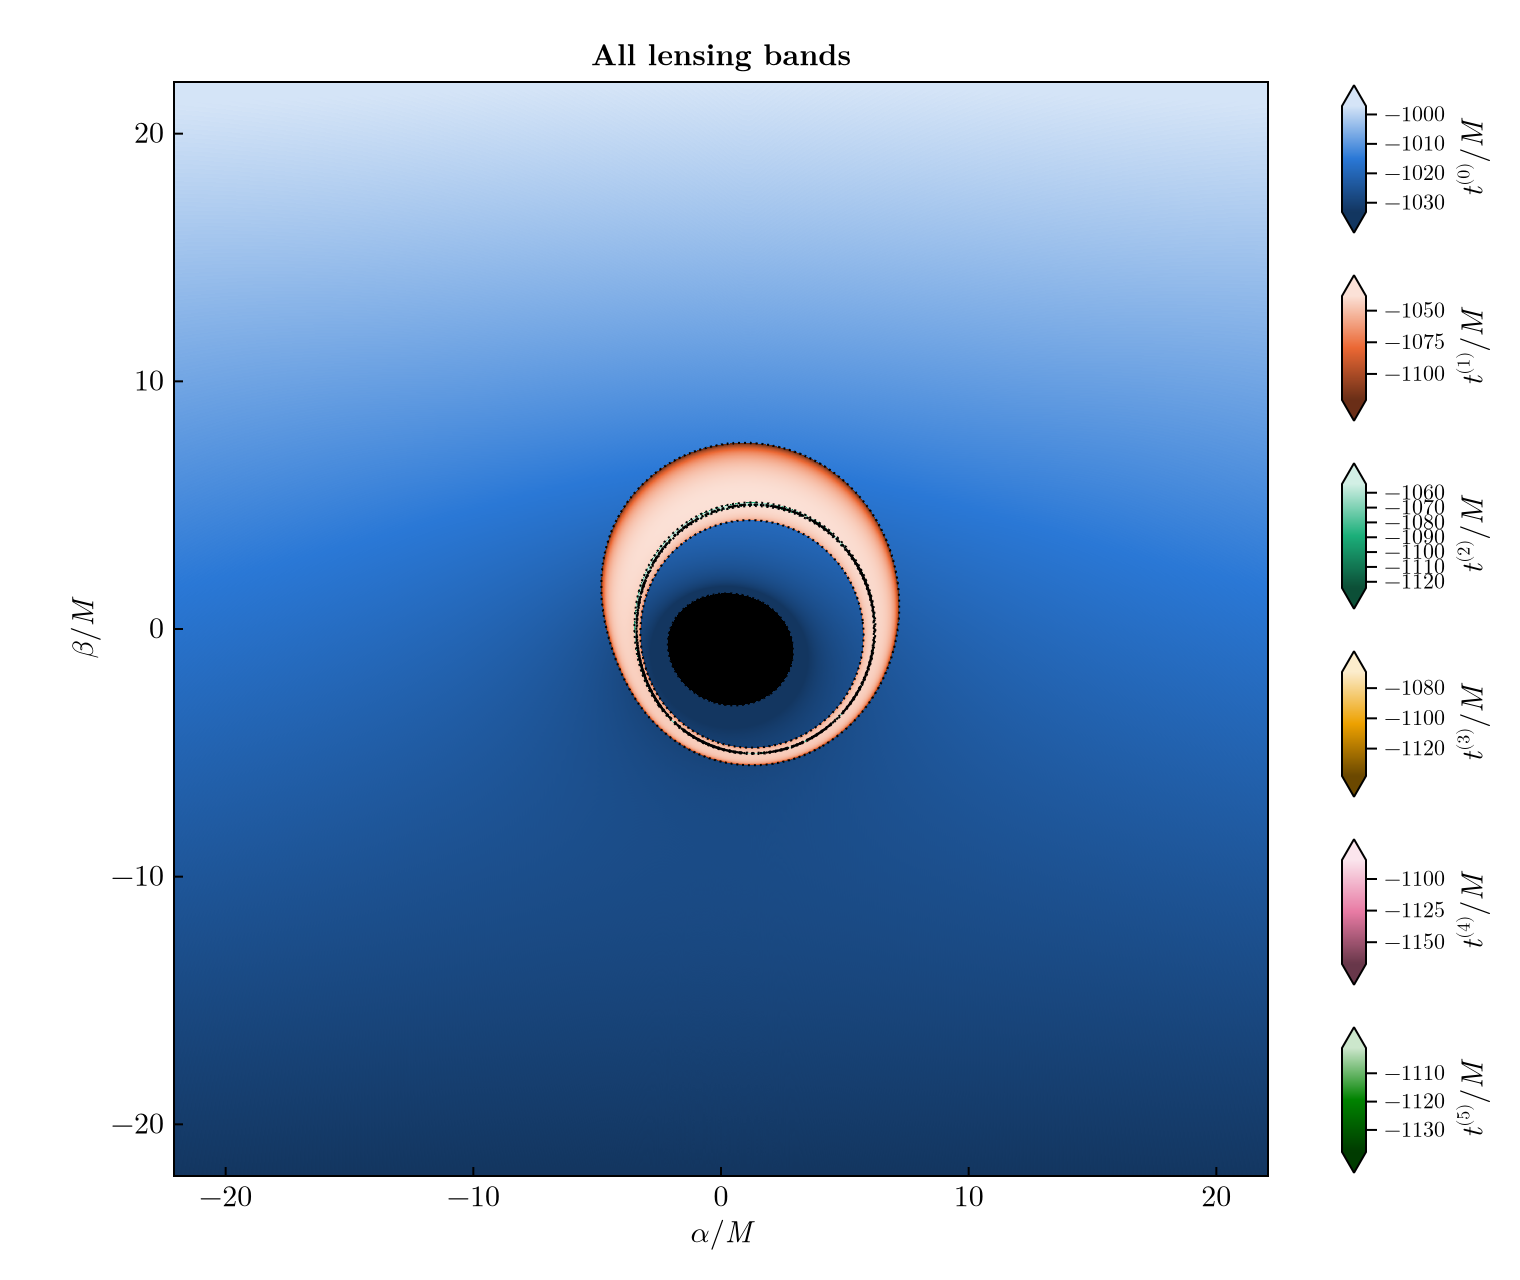

In [5]:
set_theme!(theme_latexfonts())
update_theme!(fontsize = 15, Axis = (aspect = DataAspect(), xlabel = L"\alpha / M", ylabel = L"\beta / M",
    xgridvisible = false, ygridvisible = false, xtickalign = 1, ytickalign = 1))

const COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
@assert nbands <= length(COLORS) "more bands than colours"

mixc(c, target, w) = (a = to_color(c); b = to_color(target);
    RGBf((1 - w) * a.r + w * b.r, (1 - w) * a.g + w * b.g, (1 - w) * a.b + w * b.b))
ramp(c) = cgrad([mixc(c, :black, 0.55), mixc(c, c, 0.0), mixc(c, :white, 0.8)])

function crange(m)                                   # colour range only, the data are not changed
    v = filter(isfinite, vec(m))
    lo, hi = quantile(v, 0.01), quantile(v, 0.99)
    return lo < hi ? (lo, hi) : (lo - 0.5, hi + 0.5)
end

function band_map!(ax, n)
    cm = ramp(COLORS[n + 1])
    heatmap!(ax, α, β, τ[n + 1]; colormap = cm, colorrange = crange(τ[n + 1]),
             lowclip = cm[0.0], highclip = cm[1.0], nan_color = :transparent)
end
shadow!(ax) = heatmap!(ax, α, β, map(x -> x ? 1.0 : NaN, inner_shadow);
                       colormap = [:black, :black], colorrange = (0, 2), nan_color = :transparent)
boundary!(ax, n) = contour!(ax, α, β, Float64.(ncross .>= n + 1);
                            levels = [0.5], color = :black, linestyle = :dot, linewidth = 1)

fig1 = Figure(size = (760, 640))
ax1  = Axis(fig1[1, 1]; title = "All lensing bands")
hms  = [band_map!(ax1, n) for n in 0:(nbands - 1)]
shadow!(ax1)
foreach(n -> boundary!(ax1, n), 0:(nbands - 1))
cbs = fig1[1, 2] = GridLayout()
for n in 0:(nbands - 1)
    Colorbar(cbs[n + 1, 1], hms[n + 1]; label = L"t^{(%$n)} / M", ticklabelsize = 11)
end
resize_to_layout!(fig1)
fig1

## Each band separately

Band 0 on the full screen; the indirect bands share a zoom on the region of rays that cross at least twice.

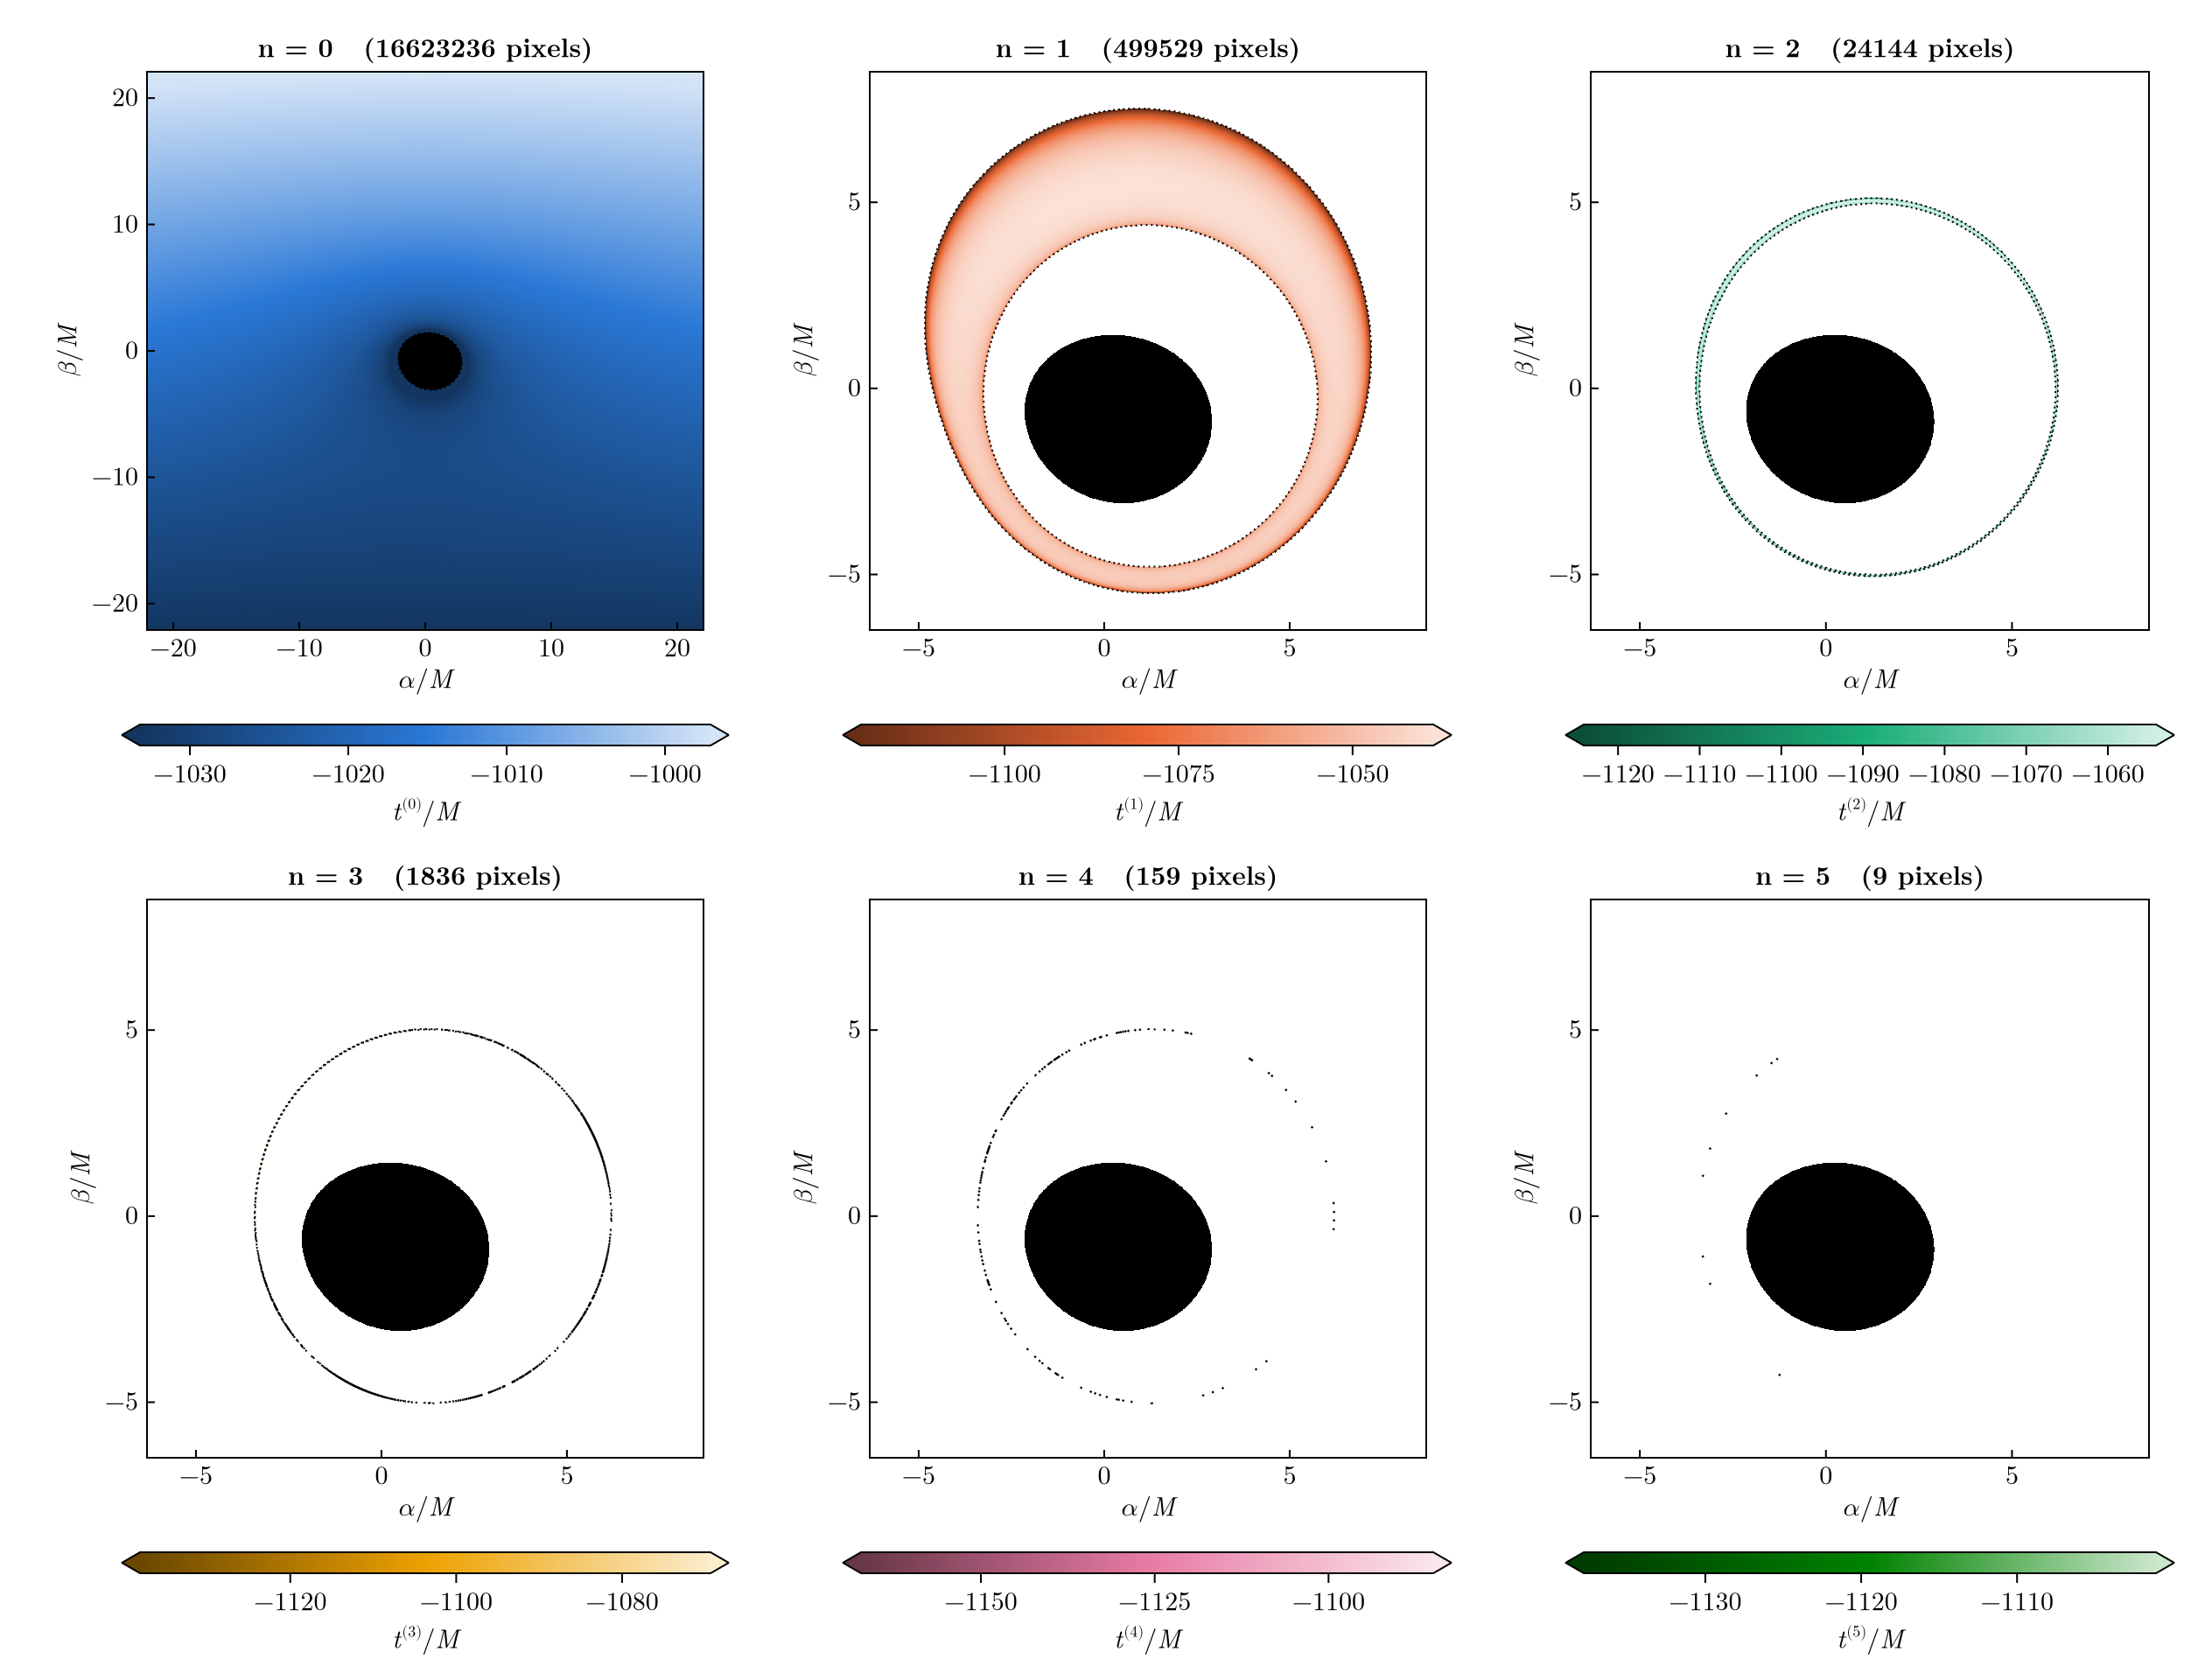

In [6]:
function zoom_box(mask; pad = 0.15)
    idx = findall(mask)
    isempty(idx) && return nothing
    x, y = α[[I[1] for I in idx]], β[[I[2] for I in idx]]
    cx, cy = (minimum(x) + maximum(x)) / 2, (minimum(y) + maximum(y)) / 2
    h = (1 + pad) * max(maximum(x) - minimum(x), maximum(y) - minimum(y)) / 2 + 2 * (α[2] - α[1])
    return (cx - h, cx + h, cy - h, cy + h)
end
box = zoom_box(ncross .>= 2)

ncol = min(nbands, 3)
fig2 = Figure(size = (420 * ncol, 480 * cld(nbands, ncol)))
for n in 0:(nbands - 1)
    r, c = 2 * (n ÷ ncol) + 1, n % ncol + 1
    ax = Axis(fig2[r, c]; title = "n = $n   ($(count(isfinite, τ[n + 1])) pixels)")
    hm = band_map!(ax, n)
    shadow!(ax)
    boundary!(ax, n)
    (n > 0 && box !== nothing) && limits!(ax, box...)
    Colorbar(fig2[r + 1, c], hm; vertical = false, flipaxis = false, label = L"t^{(%$n)} / M")
end
resize_to_layout!(fig2)
fig2

## Histogram of the crossing times

Counts of the band times in bins of `BIN` M. The populations differ by orders of magnitude, so the
y axis is broken into stacked segments (one per scale of the band peaks) to keep the small bands visible.

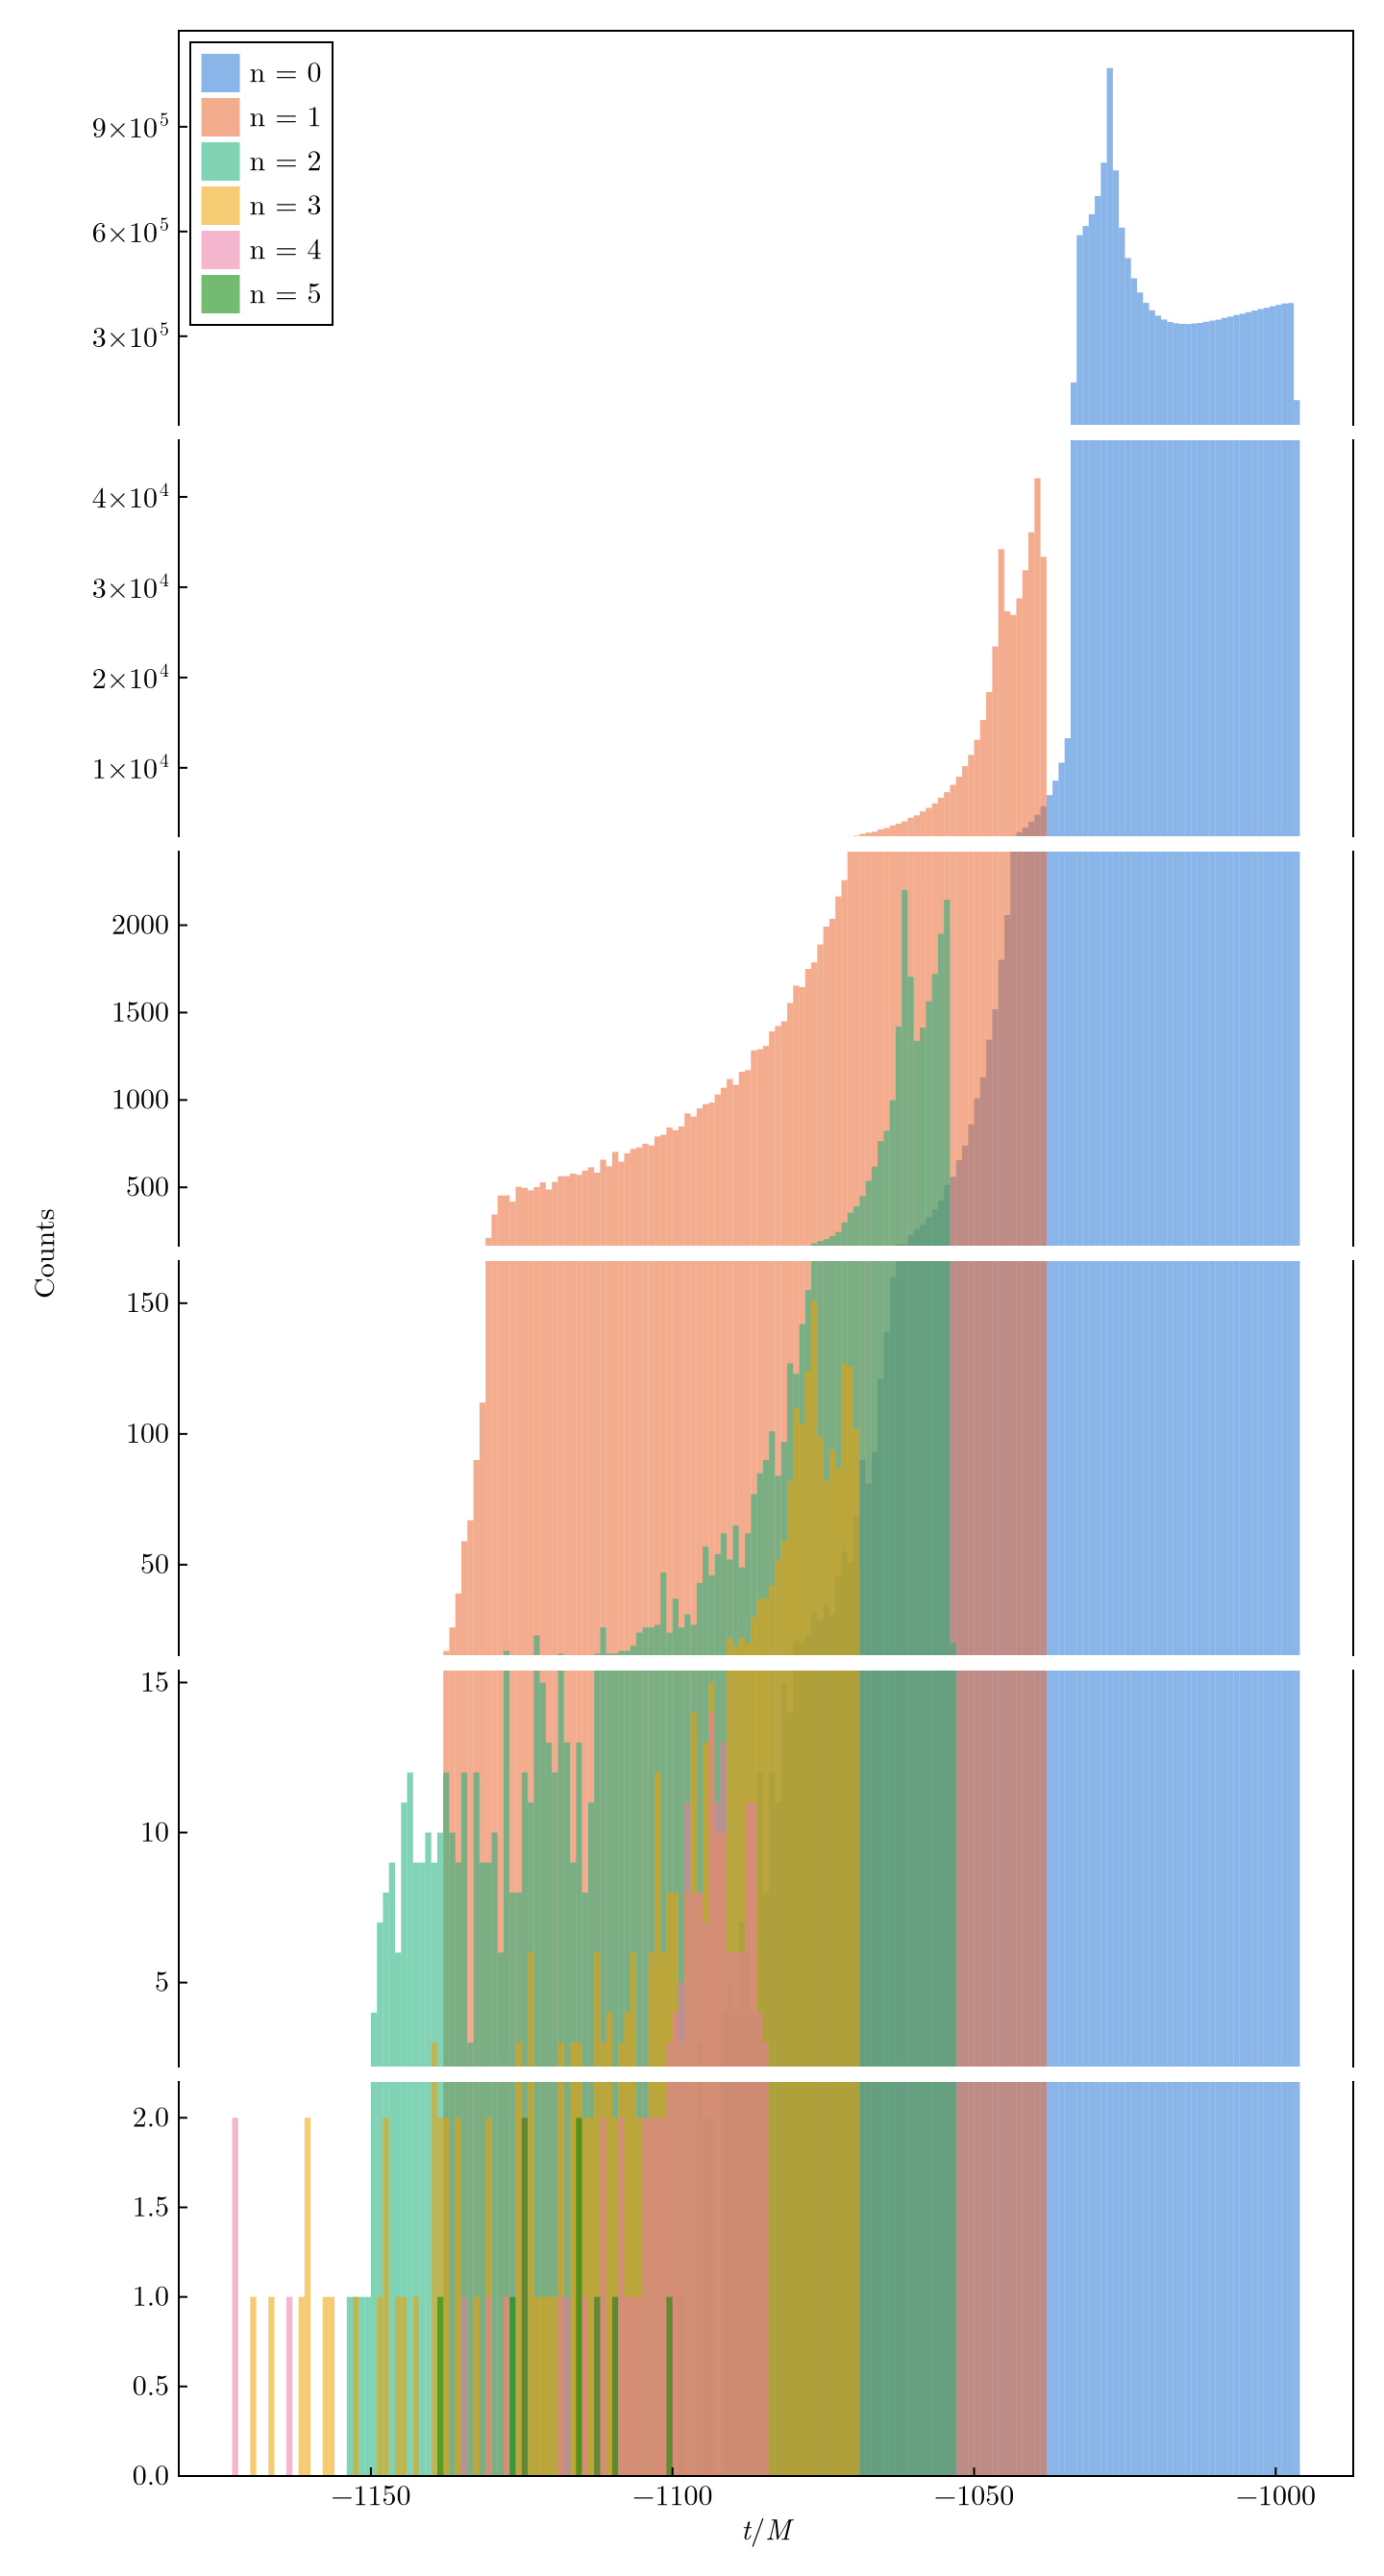

In [7]:
const BIN = 1.0                                      # bin width (M)

ts_band = [filter(isfinite, vec(τ[n + 1])) for n in 0:(nbands - 1)]
lo      = floor(minimum(minimum, ts_band))
nbins   = floor(Int, (maximum(maximum, ts_band) - lo) / BIN) + 1
centers = lo .+ BIN .* ((1:nbins) .- 0.5)
counts  = map(ts_band) do v
    h = zeros(Int, nbins)
    foreach(t -> h[floor(Int, (t - lo) / BIN) + 1] += 1, v)
    h
end

# y segments: a new segment whenever a band peak is more than 4x the previous scale
tops = Float64[]
for pk in sort(unique(maximum.(counts)))
    (isempty(tops) || pk > 4 * tops[end]) ? push!(tops, pk) : (tops[end] = pk)
end
tops .*= 1.1
lows = [0.0; tops[1:(end - 1)]]
nseg = length(tops)

fig3 = Figure(size = (720, 200 * nseg + 140))
axs  = [Axis(fig3[k, 1]; aspect = nothing, xlabel = L"t / M", ylabel = "") for k in 1:nseg]
for (k, ax) in enumerate(axs)
    s = nseg - k + 1                                 # top row shows the largest counts
    for n in 0:(nbands - 1)
        barplot!(ax, centers, counts[n + 1]; width = BIN, gap = 0, strokewidth = 0,
                 color = (COLORS[n + 1], 0.55), label = "n = $n")
    end
    ylims!(ax, lows[s], tops[s])
    k < nseg && (hidexdecorations!(ax); ax.bottomspinevisible = false)
    k > 1 && (ax.topspinevisible = false)
end
linkxaxes!(axs...)
rowgap!(fig3.layout, 8)
Label(fig3[:, 0], "Counts"; rotation = π / 2)
axislegend(axs[1]; position = :lt)
fig3

---
# Section 2 — 